# Deep Learning (CS 405) - Lab
## Experiment: Generating Novel Fashion Images using Variational Autoencoders (VAEs)

**Name:** Nabeel Shan

### 1. Environment & Dependencies
Initializes core libraries (NumPy, Matplotlib) and standard Keras components for building the VAE architecture.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape, Layer
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.datasets import fashion_mnist

### 2. Data Preprocessing
Loads Fashion-MNIST, normalizes pixel intensities to $[0, 1]$ to match the decoder's Sigmoid activation, and reshapes tensors to `(28, 28, 1)` for spatial convolutions.

In [ ]:
# Load and prepare the dataset
(train_x, train_y), (val_x, val_y) = fashion_mnist.load_data()

# Normalize pixel values to [0, 1]
train_x = train_x.astype('float32') / 255.
val_x = val_x.astype('float32') / 255.

# Reshape to explicitly include the channel dimension (28, 28, 1) for CNNs
train_x = train_x.reshape(-1, 28, 28, 1)
val_x = val_x.reshape(-1, 28, 28, 1)

print(f"Training data shape: {train_x.shape}")
print(f"Validation data shape: {val_x.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Validation data shape: (10000, 28, 28, 1)


### 3. CNN Encoder & Reparameterization Trick
Extracts spatial features via strided convolutions and maps them to latent distribution parameters: mean ($\mu$) and log-variance ($\log \sigma^2$). Implements the reparameterization trick: $z = \mu + \sigma \odot \epsilon$.

In [ ]:
batch_size = 128 # Increased from 16 for much better/stable gradients
latent_dim = 2   # 2D space so we can easily visualize it later

# --- ENCODER ---
input_img = Input(shape=(28, 28, 1), name="encoder_input")

# Convolutional layers to extract spatial features
x = Conv2D(32, 3, padding='same', activation='relu', strides=(2, 2))(input_img) # 14x14
x = Conv2D(64, 3, padding='same', activation='relu', strides=(2, 2))(x)         # 7x7
x = Conv2D(64, 3, padding='same', activation='relu')(x)                         # 7x7
x = Conv2D(64, 3, padding='same', activation='relu')(x)                         # 7x7

# Save the shape so the decoder knows how to un-flatten it later
shape_before_flattening = K.int_shape(x)

x = Flatten()(x)
x = Dense(32, activation='relu')(x)

# The Latent Space: Mean and Log-Variance
z_mu = Dense(latent_dim, name="z_mu")(x)
z_log_sigma = Dense(latent_dim, name="z_log_sigma")(x)

# --- SAMPLING FUNCTION (The Reparameterization Trick) ---
def sampling(args):
    z_mu, z_log_sigma = args
    # Sample epsilon from standard normal distribution
    epsilon = K.random_normal(shape=(K.shape(z_mu)[0], latent_dim), mean=0., stddev=1.)
    # z = mu + sigma * epsilon
    return z_mu + K.exp(0.5 * z_log_sigma) * epsilon # 0.5 because it's log variance

z = Lambda(sampling, output_shape=(latent_dim,), name="z_sampled")([z_mu, z_log_sigma])

In [ ]:
encoder = Model(input_img, [z_mu, z_log_sigma, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 64)  │     36,928 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     36,928 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │    100,384 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mu (Dense)        │ (None, 2)         │         66 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_sigma (Dense) │ (None, 2)         │         66 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_sampled (Lambda)  │ (None, 2)         │          0 │ z_mu[0][0],       │
│                     │                   │            │ z_log_sigma[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 193,188 (754.64 KB)

 Trainable params: 193,188 (754.64 KB)

 Non-trainable params: 0 (0.00 B)

### 4. CNN Decoder
Projects the sampled latent vector $z$ back to the original input dimensions using transposed convolutions, outputting reconstructed pixel probabilities.

In [ ]:
# --- DECODER ---
# Input matches the latent dimension (2,)
decoder_input = Input(shape=(latent_dim,), name="decoder_input")

# Expand back to the flattened representation size
num_neurons = shape_before_flattening[1] * shape_before_flattening[2] * shape_before_flattening[3]
x = Dense(num_neurons, activation='relu')(decoder_input)

# Reshape back to 3D tensor (e.g., 7x7x64)
x = Reshape(shape_before_flattening[1:])(x)

# Transposed Convolutions (Deconvolution) to upscale back to 28x28
x = Conv2DTranspose(64, 3, padding='same', activation='relu', strides=(2, 2))(x) # 14x14
x = Conv2DTranspose(32, 3, padding='same', activation='relu', strides=(2, 2))(x) # 28x28

# Final output layer: 1 channel, sigmoid activation to output pixel values in [0,1]
decoder_output = Conv2D(1, 3, padding='same', activation='sigmoid', name="decoder_output")(x)

In [ ]:
decoder = Model(decoder_input, decoder_output, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

### 5. ELBO Loss Function & Model Compilation
Implements a custom layer to optimize the Evidence Lower Bound (ELBO). Combines Binary Cross-Entropy (Reconstruction Loss) with KL Divergence ($D_{KL}$) to regularize the latent space to $\mathcal{N}(0, 1)$.

In [ ]:
# Apply decoder to the sampled latent vector
z_decoded = decoder(z)

# --- CUSTOM LOSS LAYER ---
class CustomVariationalLayer(Layer):
    def vae_loss(self, x, z_decoded, z_mu, z_log_sigma):
        # Flatten inputs for binary crossentropy
        x = K.flatten(x)
        z_decoded = K.flatten(z_decoded)

        # 1. Reconstruction Loss (How well did we recreate the image?)
        # Multiply by 28*28 to sum over all pixels instead of taking the mean
        xent_loss = 28 * 28 * binary_crossentropy(x, z_decoded)

        # 2. KL Divergence (How close is latent space to standard normal?)
        # Mathematically optimizing the Evidence Lower Bound (ELBO)
        kl_loss = -0.5 * K.sum(1 + z_log_sigma - K.square(z_mu) - K.exp(z_log_sigma), axis=-1)

        # Total Loss
        return K.mean(xent_loss + kl_loss)

    def call(self, inputs):
        x = inputs[0]
        z_decoded = inputs[1]
        z_mu = inputs[2]
        z_log_sigma = inputs[3]

        loss = self.vae_loss(x, z_decoded, z_mu, z_log_sigma)

        # THE FIX: Removed 'inputs=inputs'. Modern Keras tracks the graph automatically.
        self.add_loss(loss)

        return x # Return the input tensor unmodified to satisfy layer requirements

# Connect the custom layer
y = CustomVariationalLayer()([input_img, z_decoded, z_mu, z_log_sigma])

### 6. Model Training
Executes the training loop across the dataset using the `RMSprop` optimizer, storing epoch-level metrics in the `history` object.

In [ ]:
# --- VAE MODEL STATEMENT ---
vae = Model(input_img, y, name="vae")
vae.compile(optimizer='rmsprop')

In [ ]:
# Train the VAE
epochs = 20

history = vae.fit(
    x=train_x,
    y=None, # y is None because the custom layer handles the labels natively
    shuffle=True,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(val_x, None)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 332.1511 - val_loss: 290.0468
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 283.2982 - val_loss: 279.4962
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 276.1835 - val_loss: 272.0058
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 272.3335 - val_loss: 273.4514
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 270.0806 - val_loss: 275.1277
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 268.3313 - val_loss: 267.5383
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 266.9841 - val_loss: 267.4132
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 266.0025 - val_loss: 268.9674
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 265.2089 - val_loss: 265.6070
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 264.2483 - val_loss: 267.2312
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 263.4567 - val_loss: 267.3859
Epoch 

### 7. Continuous Latent Space Visualization
Samples a uniform grid across the 2D probabilistic space using the inverse CDF (`norm.ppf`) to generate a continuous manifold of novel fashion items.

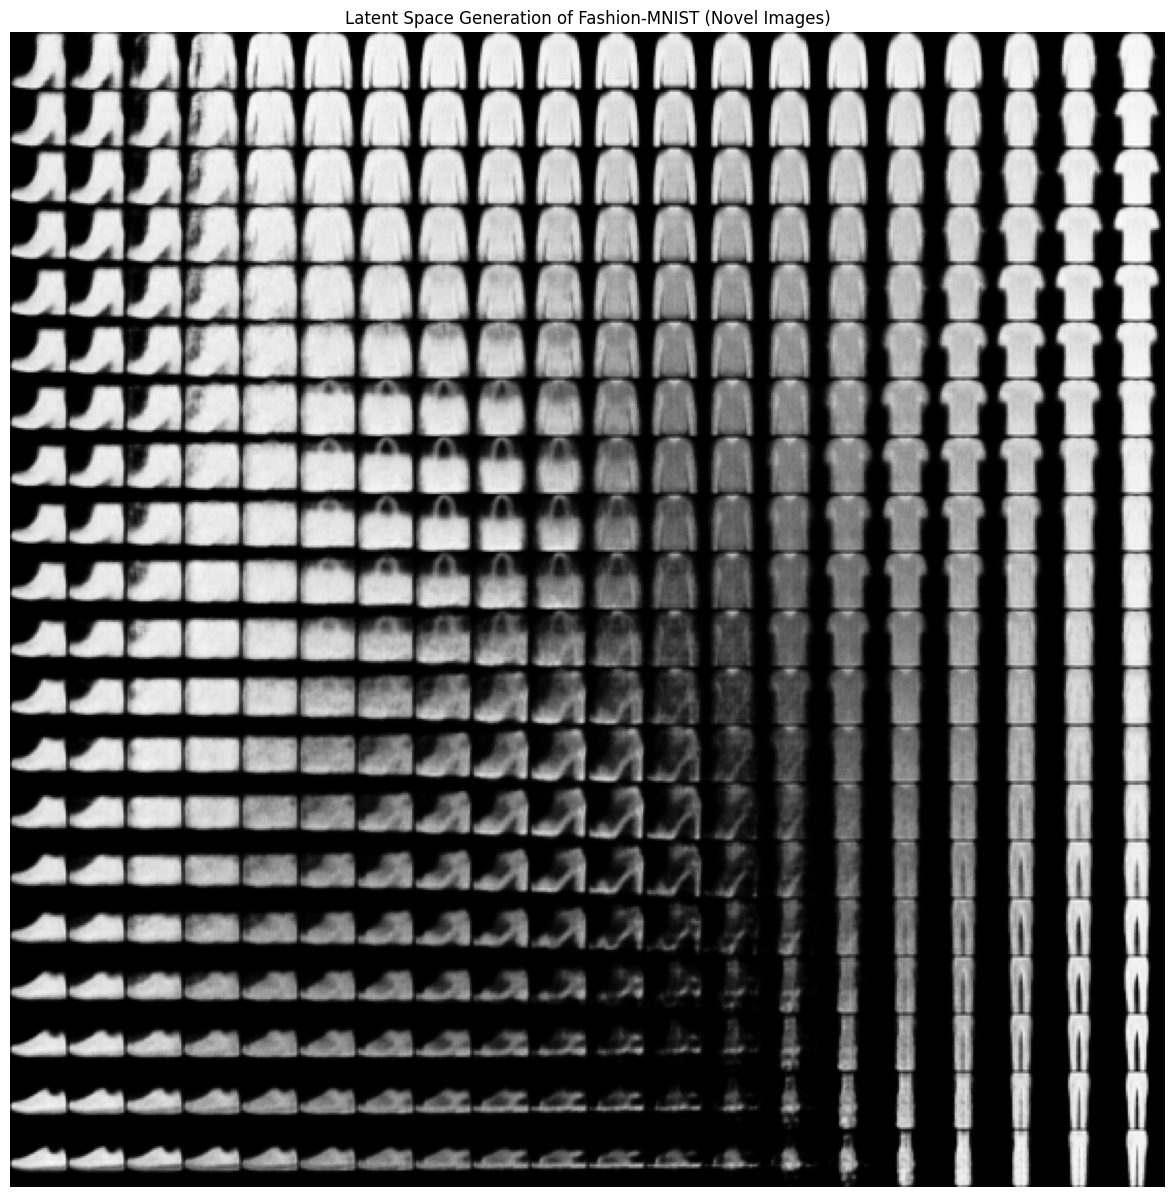

In [ ]:
# Display a 2D manifold of the samples
n = 20  # figure with 20x20 samples
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# Construct grid of latent variable values
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

# decode for each square in the grid
for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z_sample = np.array([[xi, yi]])
        # Predict uses the decoder to map the latent point back to image space
        x_decoded = decoder.predict(z_sample, verbose=0)

        digit = x_decoded[0].reshape(digit_size, digit_size)

        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(15, 15))
plt.imshow(figure, cmap='Greys_r')
plt.title("Latent Space Generation of Fashion-MNIST (Novel Images)")
plt.axis('off')
plt.show()

### 8. Training Convergence Analysis
Visualizes training versus validation ELBO loss curves to verify model convergence and monitor for overfitting.

In [ ]:
import matplotlib.pyplot as plt

# Extract the loss values from the Keras history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# Set up the visual plot
plt.figure(figsize=(10, 6))

# Plot Training vs Validation Loss
plt.plot(epochs, train_loss, 'b-', linewidth=2, label='Training Loss (ELBO)')
plt.plot(epochs, val_loss, 'r--', linewidth=2, label='Validation Loss (ELBO)')

# Formatting for professional presentation
plt.title('VAE Training History: Total Loss Convergence', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Reconstruction + KL Divergence)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape, Layer, Conv2D, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.losses import binary_crossentropy

In [ ]:
# Define the custom loss layer globally so it can be reused
class CustomVariationalLayer(Layer):
    def vae_loss(self, x, z_decoded, z_mu, z_log_sigma):
        x = K.flatten(x)
        z_decoded = K.flatten(z_decoded)
        xent_loss = 28 * 28 * binary_crossentropy(x, z_decoded)
        kl_loss = -0.5 * K.sum(1 + z_log_sigma - K.square(z_mu) - K.exp(z_log_sigma), axis=-1)
        return K.mean(xent_loss + kl_loss)

    def call(self, inputs):
        x, z_decoded, z_mu, z_log_sigma = inputs
        loss = self.vae_loss(x, z_decoded, z_mu, z_log_sigma)
        self.add_loss(loss)
        return x

### Task Setup: Dynamic VAE Builder
A modular wrapper function to dynamically instantiate, compile, and train VAE architectures with arbitrary latent dimensions and epoch limits.

In [ ]:
def build_and_train_vae(latent_dim, epochs, train_x, val_x, batch_size=128):
    """Dynamically builds and trains a VAE."""
    tf.keras.backend.clear_session() # Clears previous models from memory

    # --- ENCODER ---
    input_img = Input(shape=(28, 28, 1))
    x = Conv2D(32, 3, padding='same', activation='relu', strides=(2, 2))(input_img)
    x = Conv2D(64, 3, padding='same', activation='relu', strides=(2, 2))(x)
    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    shape_before_flattening = K.int_shape(x)

    x = Flatten()(x)
    x = Dense(32, activation='relu')(x)
    z_mu = Dense(latent_dim)(x)
    z_log_sigma = Dense(latent_dim)(x)

    def sampling(args):
        z_mu, z_log_sigma = args
        epsilon = K.random_normal(shape=(K.shape(z_mu)[0], latent_dim), mean=0., stddev=1.)
        return z_mu + K.exp(0.5 * z_log_sigma) * epsilon

    z = Lambda(sampling, output_shape=(latent_dim,))([z_mu, z_log_sigma])
    encoder = Model(input_img, [z_mu, z_log_sigma, z])

    # --- DECODER ---
    decoder_input = Input(shape=(latent_dim,))
    num_neurons = shape_before_flattening[1] * shape_before_flattening[2] * shape_before_flattening[3]
    x = Dense(num_neurons, activation='relu')(decoder_input)
    x = Reshape(shape_before_flattening[1:])(x)
    x = Conv2DTranspose(64, 3, padding='same', activation='relu', strides=(2, 2))(x)
    x = Conv2DTranspose(32, 3, padding='same', activation='relu', strides=(2, 2))(x)
    decoder_output = Conv2D(1, 3, padding='same', activation='sigmoid')(x)
    decoder = Model(decoder_input, decoder_output)

    # --- VAE COMPILE & TRAIN ---
    z_decoded = decoder(z)
    y = CustomVariationalLayer()([input_img, z_decoded, z_mu, z_log_sigma])
    vae = Model(input_img, y)
    vae.compile(optimizer='rmsprop')

    print(f"\n--- Training VAE with Latent Dim: {latent_dim} for {epochs} Epochs ---")
    history = vae.fit(x=train_x, y=None, shuffle=True, epochs=epochs,
                      batch_size=batch_size, validation_data=(val_x, None), verbose=1)

    return vae, encoder, decoder, history

### Task 1: The Information Bottleneck (2D vs. 10D)
Evaluates architectural capacity. Compares the generative sharpness of a heavily constrained 2-dimensional latent space against a higher-capacity 10-dimensional representation.


--- Training VAE with Latent Dim: 2 for 10 Epochs ---
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 321.2742 - val_loss: 287.6129
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 282.3693 - val_loss: 281.9872
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 275.4407 - val_loss: 277.1799
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 272.0937 - val_loss: 270.1865
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 269.8531 - val_loss: 267.4671
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 268.0524 - val_loss: 269.6140
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 266.5073 - val_loss: 267.1026
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 265.3146 - val_loss: 264.4325
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 264.0934 - val_loss: 273.7871
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 263.2363 - val_loss: 263.4435

--- Training VAE with Latent Dim: 10 f

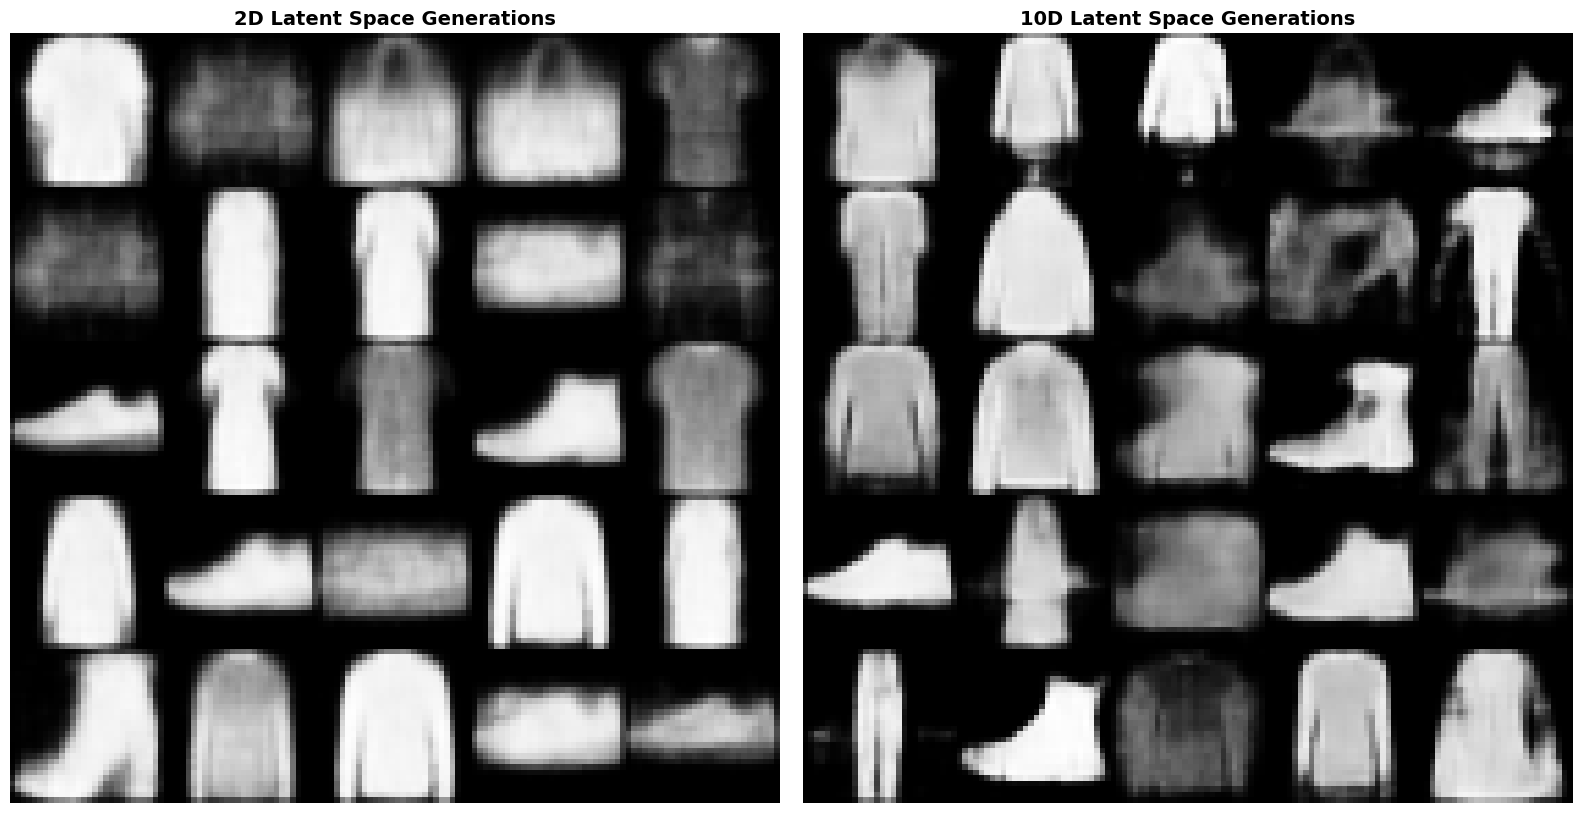

In [ ]:
# Train both models
_, _, decoder_2d, _ = build_and_train_vae(latent_dim=2, epochs=10, train_x=train_x, val_x=val_x)
_, _, decoder_10d, _ = build_and_train_vae(latent_dim=10, epochs=10, train_x=train_x, val_x=val_x)

def plot_random_samples(decoder, latent_dim, title, ax):
    """Generates a 5x5 grid of random novel samples."""
    n = 5
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))

    # Sample randomly from standard normal distribution N(0, 1)
    random_latent_vectors = np.random.normal(size=(n * n, latent_dim))
    decoded_imgs = decoder.predict(random_latent_vectors, verbose=0)

    idx = 0
    for i in range(n):
        for j in range(n):
            digit = decoded_imgs[idx].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit
            idx += 1

    ax.imshow(figure, cmap='Greys_r')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_random_samples(decoder_2d, 2, "2D Latent Space Generations", axes[0])
plot_random_samples(decoder_10d, 10, "10D Latent Space Generations", axes[1])
plt.tight_layout()
plt.show()

### Task 2: Convergence Comparison (5 vs. 30 Epochs)
Analyzes the impact of training duration on the loss surface. Compares gradient descent trajectories of an underfitted model (5 epochs) versus a converged model (30 epochs).

In [ ]:
# Train for 5 epochs (using 2D for speed)
_, _, _, history_5 = build_and_train_vae(latent_dim=2, epochs=5, train_x=train_x, val_x=val_x)

# Train for 30 epochs
_, _, _, history_30 = build_and_train_vae(latent_dim=2, epochs=30, train_x=train_x, val_x=val_x)


--- Training VAE with Latent Dim: 2 for 5 Epochs ---
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 318.7258 - val_loss: 288.3242
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 281.9849 - val_loss: 277.4731
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 275.8004 - val_loss: 278.1509
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 272.4261 - val_loss: 270.7471
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 269.9929 - val_loss: 270.4937

--- Training VAE with Latent Dim: 2 for 30 Epochs ---
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 326.0881 - val_loss: 294.3603
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 285.5027 - val_loss: 284.8807
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 277.9398 - val_loss: 278.2519
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 273.8936 - val_loss: 271.4393
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 271.4202 - val_loss: 2

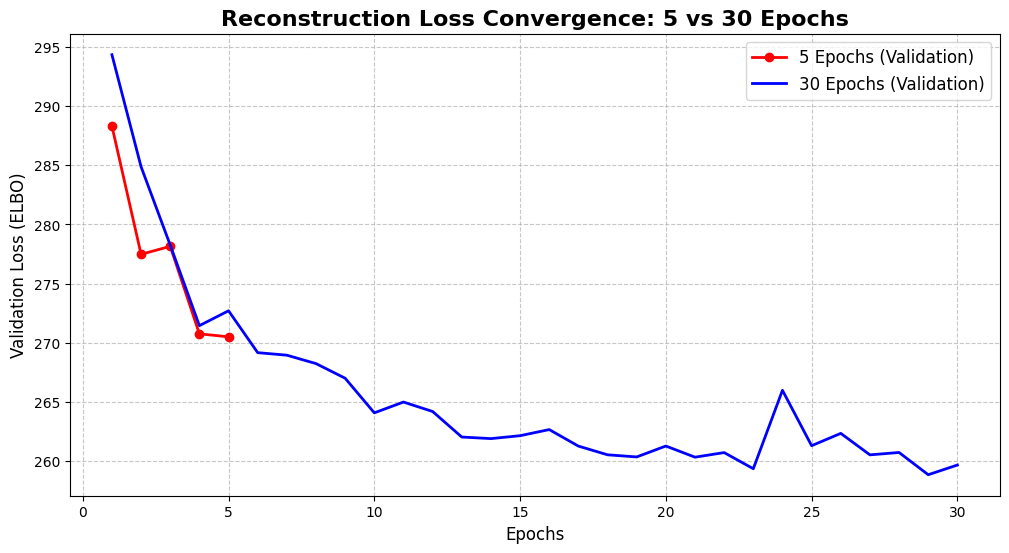

In [ ]:
# Plotting the comparison
plt.figure(figsize=(12, 6))

# Plot the 5-epoch run
epochs_5_range = range(1, 6)
plt.plot(epochs_5_range, history_5.history['val_loss'], 'r-o', label='5 Epochs (Validation)', linewidth=2)

# Plot the 30-epoch run
epochs_30_range = range(1, 31)
plt.plot(epochs_30_range, history_30.history['val_loss'], 'b-', label='30 Epochs (Validation)', linewidth=2)

plt.title('Reconstruction Loss Convergence: 5 vs 30 Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Loss (ELBO)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Task 3: Manual Latent Space Injection
Bypasses the probabilistic encoder to manually query specific deterministic coordinates ($z$) in the latent distribution, executing direct generative control over the decoder.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step


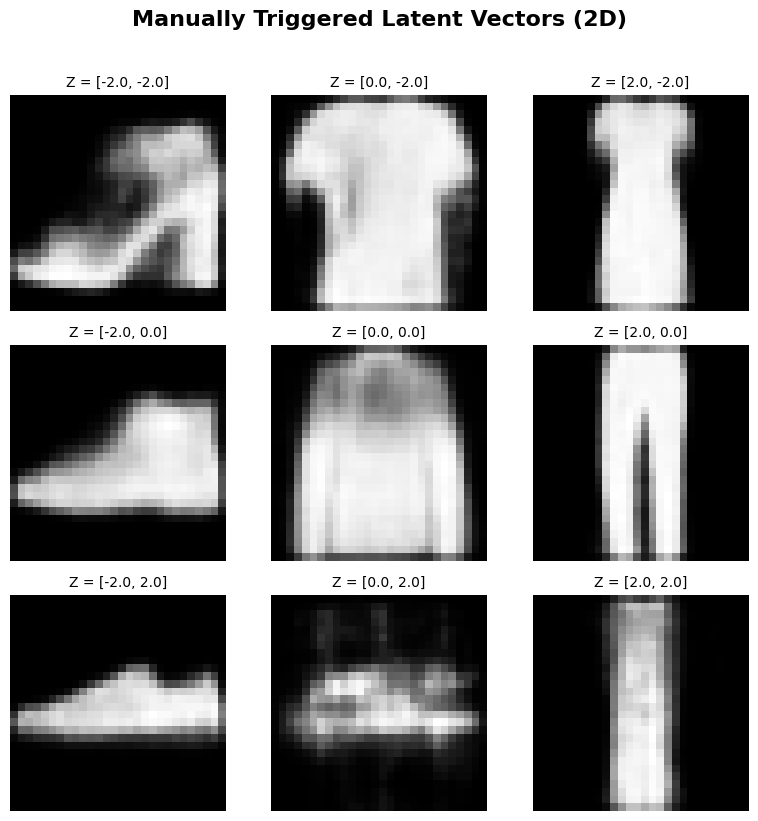

In [ ]:
# We will use the 2D decoder from Task 1 because it's easiest to manually target X,Y coordinates.
manual_latent_values = np.array([
    [-2.0, -2.0], [ 0.0, -2.0], [ 2.0, -2.0],
    [-2.0,  0.0], [ 0.0,  0.0], [ 2.0,  0.0],
    [-2.0,  2.0], [ 0.0,  2.0], [ 2.0,  2.0]
])

# Pass these exact values directly to the decoder
generated_images = decoder_2d.predict(manual_latent_values)

# Setup the 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle("Manually Triggered Latent Vectors (2D)", fontsize=16, fontweight='bold', y=1.02)

idx = 0
for i in range(3):
    for j in range(3):
        # Extract image and reshape
        img = generated_images[idx].reshape(28, 28)

        # Plot
        axes[i, j].imshow(img, cmap='Greys_r')
        axes[i, j].set_title(f"Z = [{manual_latent_values[idx][0]}, {manual_latent_values[idx][1]}]", fontsize=10)
        axes[i, j].axis('off')
        idx += 1

plt.tight_layout()
plt.show()